In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

In [2]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [3]:
receiver = "../data/AM_automotive_testbench/STL/receiver.stl"

In [4]:
stl = r"../data/lab_testbench/STL/AB.stl"
xlsx = r"../data/lab_testbench/Measurements/AM_Measurements.xlsx"

full_file = r'..\data\lab_testbench\FEM\AB\file.full'
ress_file = r'..\data\lab_testbench\FEM\AB\file.rst'

In [27]:
MK = pyFBS.MK_model(ress_file,full_file,no_modes = 100,recalculate = False)
MK.mesh.points *= 1000

In [6]:
view3D = pyFBS.display.view3D(show_origin= True)

In [23]:
#view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 0.8)

In [28]:
view3D.plot.add_mesh(MK.mesh, scalars = np.ones(MK.mesh.points.shape[0]),show_scalar_bar = False,name = "mesh",cmap = "coolwarm",show_edges = True)

(vtkRenderingOpenGL2Python.vtkOpenGLActor)000001D3AB8A6F48

In [9]:
pts = MK.mesh.points.copy()

In [10]:
view3D.take_gif = False

In [11]:
# Priprava animacije oblike
select_mode = 10   
relative_scale = 30

#kreairanje animacije
_modeshape = np.zeros_like(MK.nodes)
for ref,mode in zip(MK.dof_ref,MK.eig_vec[:,select_mode]):
    _modeshape[ref[0]-1,ref[1]] = mode

#samo priprava vsega za onimacijo v pyFBSu
mode_dict = dict()
mode_dict["animation_pts"] = mode_animation(_modeshape,relative_scale,no_points = 60)
mode_dict["mesh"] = MK.mesh
mode_dict["or_pts"] = pts
mode_dict["scalars"] = True
mode_dict["fps"] = 30

#dodajanje animacije v okno
view3D.add_modeshape(mode_dict,run_animation = True)

In [32]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
#view3D.label_imp(df_imp)
#df_imp

In [13]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
#df_chn

In [30]:
df_chn_up = MK.update_locations_df(df_chn)
df_imp_up = MK.update_locations_df(df_imp)

#view3D.show_imp(df_imp_up, color = "k")


In [34]:
MK.FRF_synth(df_chn,df_imp,modal_damping = 0.003,frf_type = "accelerance")

In [35]:
freq, Y_AB_exp = np.load(r"../data/lab_testbench/Measurements/Y_AB.p",allow_pickle = True)

,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
5,Sensor 2,AM_AB_final,Translation,Acceleration,m/s^2,AM_AB_final,2,100,-0.041679,0.278838,0.0221,0.0,0.0,1.0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
0,Impact 1,AM_AB_final,1,100,Force,N,0.014311,0.207959,0.017,0.0,0.0,-1.0


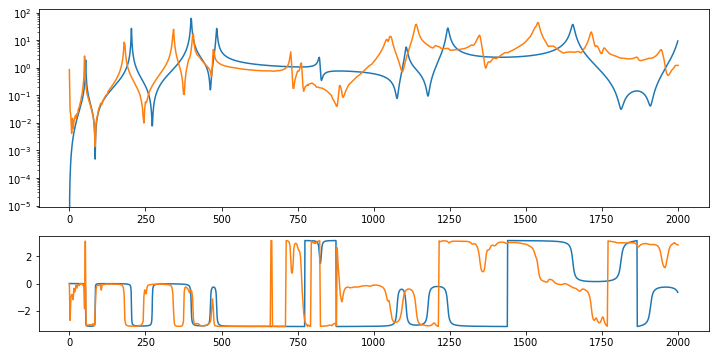

In [36]:
plt.figure(figsize = (12,8))

s1 = 5
s2 = 0

display(df_chn.iloc[[s1]])
display(df_imp.iloc[[s2]])

plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]))
plt.semilogy(freq,np.abs(Y_AB_exp[s1,s2]))


plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq,np.angle(Y_AB_exp[s1,s2]))



In [44]:
#df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
#df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')

df_chn = df_chn_up
df_imp = df_imp_up

df_vp = pd.read_excel(xlsx, sheet_name='VP_Channels')
df_vpref = pd.read_excel(xlsx, sheet_name='VP_RefChannels')

vpt = pyFBS.VPT(df_chn,df_imp,df_vp,df_vpref)

In [45]:
frf_exp = np.transpose(Y_AB_exp,(2,0,1))

vpt.apply_VPT(MK.FRF,MK.FRF)
vpt.consistency([1],[1])

In [46]:
vpt.vptData.shape

(2000, 24, 24)

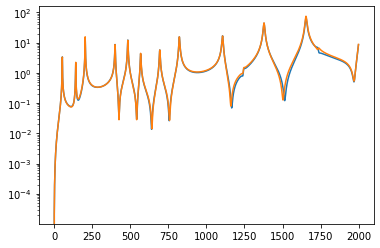

In [47]:
plt.semilogy(np.abs(vpt.u[8,:]))
plt.semilogy(np.abs(vpt.u_f[8,:]))

<BarContainer object of 9 artists>

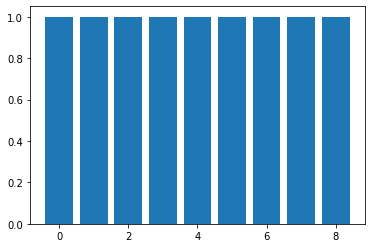

In [48]:
plt.bar(range(9),vpt.specific_sensor)

<BarContainer object of 9 artists>

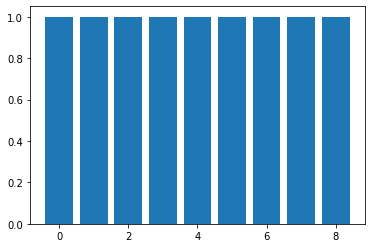

In [49]:
plt.bar(range(9),vpt.specific_impact)

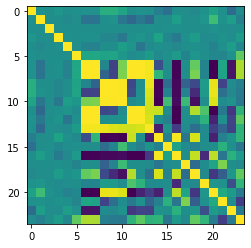

In [50]:
Y_SEMM_coh = np.zeros((24,24))

for i in range(24):
    for j in range(24):
        Y_SEMM_coh[i,j] = coh_frf(vpt.vptData[:,i,j], vpt.vptData[:,j,i])

plt.imshow(Y_SEMM_coh)